In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u 
import astropy.io.fits as fits


In [5]:
import sys

sys.path.append('/Users/jhchen/work/projects/code_snippets/utils')
sys.path.append('/Users/jhchen/work/projects/code_snippets/tasks')

In [11]:
from cube_utils import read_ALMA_cube

cubefile = '/Users/jhchen/work/data/tests/ALMA/BX610.1arcsec.cube.fits'
alma_cube = read_ALMA_cube(cubefile)

vel1 = alma_cube.get_velocity(reference=143.58*u.GHz).to(u.km/u.s).value

In [30]:
from linefit import fit_cube_gaussian

fitcube, fitmaps = fit_cube_gaussian(alma_cube.data, vel1, snr_limit=3)

/Users/jhchen/work/projects/code_snippets/tasks/linefit.py:421: RuntimeWarning: invalid value encountered in scalar power
  SNR = (chi2_sline - chi2_gauss)**0.5


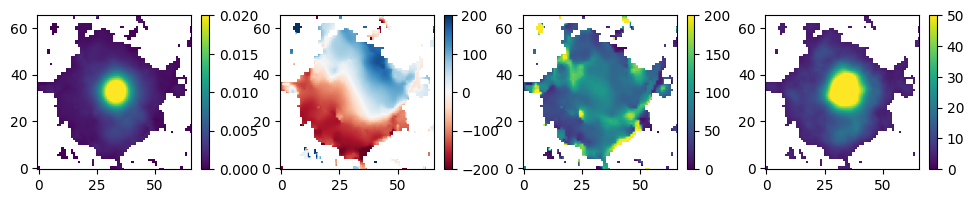

In [31]:
fig, ax = plt.subplots(1,4, figsize=(12,2))

# show the intensity, velocity, dispersion, and SNR
im = ax[0].imshow(fitmaps[0], origin='lower', vmin=0, vmax=2e-2); plt.colorbar(im, ax=ax[0])
im = ax[1].imshow(fitmaps[1], origin='lower', vmin=-200, vmax=200, cmap='RdBu'); plt.colorbar(im, ax=ax[1])
im = ax[2].imshow(fitmaps[2], origin='lower', vmin=0, vmax=200); plt.colorbar(im, ax=ax[2])
im = ax[3].imshow(fitmaps[-1], origin='lower', vmin=0, vmax=50); plt.colorbar(im, ax=ax[3])